# Analisis de Series Temporales - CityScoot

**Contexto de negocio:** CityScoot es una empresa de scooters y motos compartidas. El equipo de negocio quiere entender como evoluciona la cantidad de viajes diarios: si hay una **tendencia** de crecimiento, si existe un patron que se repite cada semana (**estacionalidad**) y que tan predecible es la serie.

En este notebook vamos a cargar la serie de viajes diarios, visualizarla, y aplicar una **descomposicion aditiva** para separar la tendencia, la estacionalidad y el residuo (lo que no explican las dos anteriores).

> **Nota:** el dataset `cityscoot_daily_rides.csv` es **simulado** (generado con numpy, semilla fija) con fines didacticos. Reproduce a proposito una tendencia creciente y una estacionalidad semanal (mas viajes los fines de semana), para que la descomposicion tenga patrones claros que interpretar.


## 1. Cargar los datos

**Por que:** antes de graficar o modelar necesitamos los datos en una estructura que sepamos manejar. Vamos a usar `pandas`, que es el estandar para trabajar con series temporales en Python: nos permite parsear fechas, ordenar por fecha y usarlas como indice.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cityscoot_daily_rides.csv", parse_dates=["fecha"])
df = df.sort_values("fecha").reset_index(drop=True)
df.head()


,fecha,viajes
0,2024-08-26,237
1,2024-08-27,227
2,2024-08-28,241
3,2024-08-29,263
4,2024-08-30,267


**Que mirar:** confirmamos que tenemos dos columnas, `fecha` y `viajes`, sin huecos evidentes. Vamos a poner `fecha` como indice para que las funciones de series temporales de `statsmodels` puedan trabajar con ella directamente.


In [2]:
serie = df.set_index("fecha")["viajes"]
print(f"Rango de fechas: {serie.index.min().date()} a {serie.index.max().date()}")
print(f"Cantidad de dias: {len(serie)}")
serie.describe()


Rango de fechas: 2024-08-26 a 2026-08-25
Cantidad de dias: 730


count    730.000000
mean     401.557534
std       79.589327
min      206.000000
25%      339.000000
50%      404.000000
75%      466.000000
max      576.000000
Name: viajes, dtype: float64

## 2. Graficar la serie completa

**Por que:** antes de aplicar cualquier tecnica estadistica, siempre conviene *mirar* los datos. Un grafico simple ya nos puede mostrar a simple vista si hay una tendencia (la serie sube o baja con el tiempo) y si hay algun patron que se repite (estacionalidad).


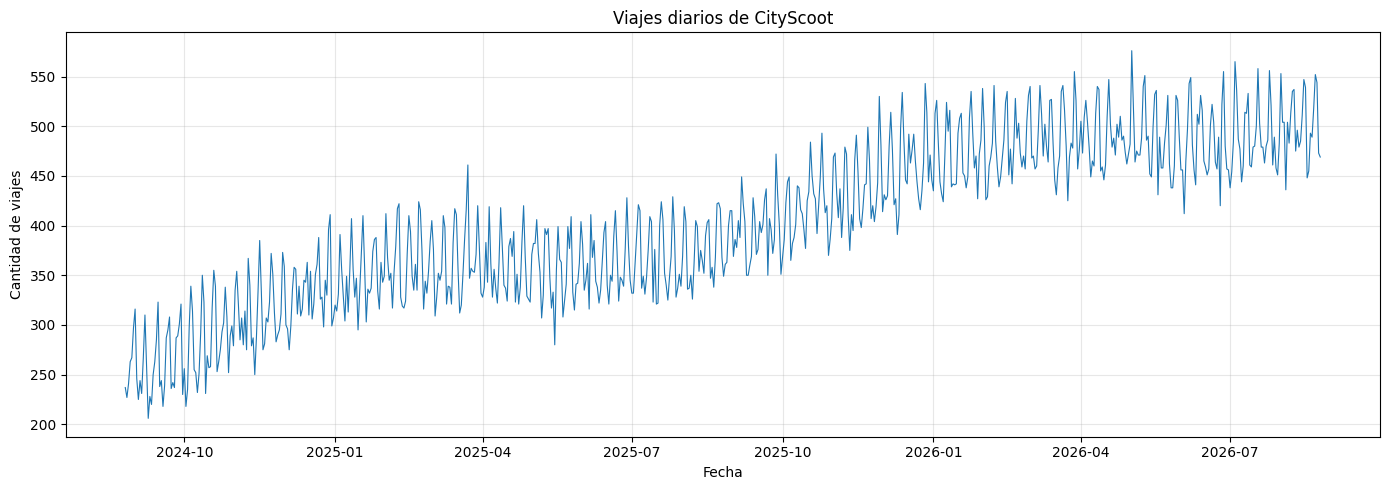

In [3]:
plt.figure(figsize=(14, 5))
plt.plot(serie.index, serie.values, color="#1f77b4", linewidth=0.8)
plt.title("Viajes diarios de CityScoot")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de viajes")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Que mirar:** en el grafico se nota una linea de fondo que va subiendo con el tiempo (la empresa crece) y un patron de "sierra" que se repite todas las semanas: eso es la estacionalidad semanal (mas movimiento los fines de semana).

Para ver ese patron semanal mas de cerca, podemos graficar solo las primeras 8 semanas.


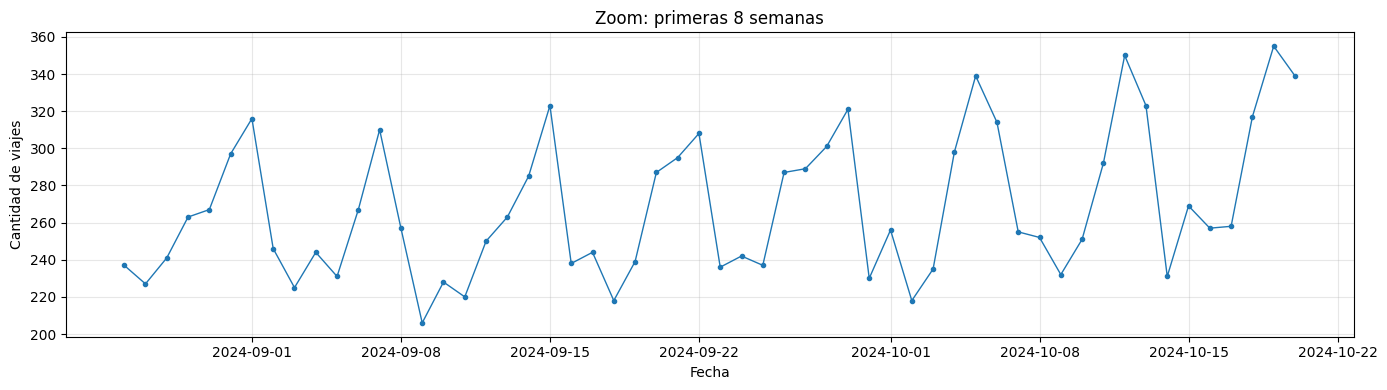

In [4]:
plt.figure(figsize=(14, 4))
plt.plot(serie.index[:56], serie.values[:56], marker="o", markersize=3, linewidth=1)
plt.title("Zoom: primeras 8 semanas")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de viajes")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Descomposicion aditiva de la serie

**Por que:** una serie temporal se puede pensar como la suma de tres partes:

- **Tendencia**: el movimiento de largo plazo (sube, baja o se mantiene estable).
- **Estacionalidad**: un patron que se repite siempre con el mismo periodo (en nuestro caso, cada 7 dias, porque los datos son diarios y el patron es semanal).
- **Residuo**: lo que sobra despues de sacar tendencia y estacionalidad, es decir, el "ruido" o variacion no explicada.

Usamos el modelo **aditivo** (`serie = tendencia + estacionalidad + residuo`) porque la amplitud del patron semanal no parece crecer proporcionalmente con el nivel de la serie (si creciera, convendria un modelo multiplicativo).

Usamos `period=7` porque nuestros datos son diarios y el ciclo que se repite es semanal.


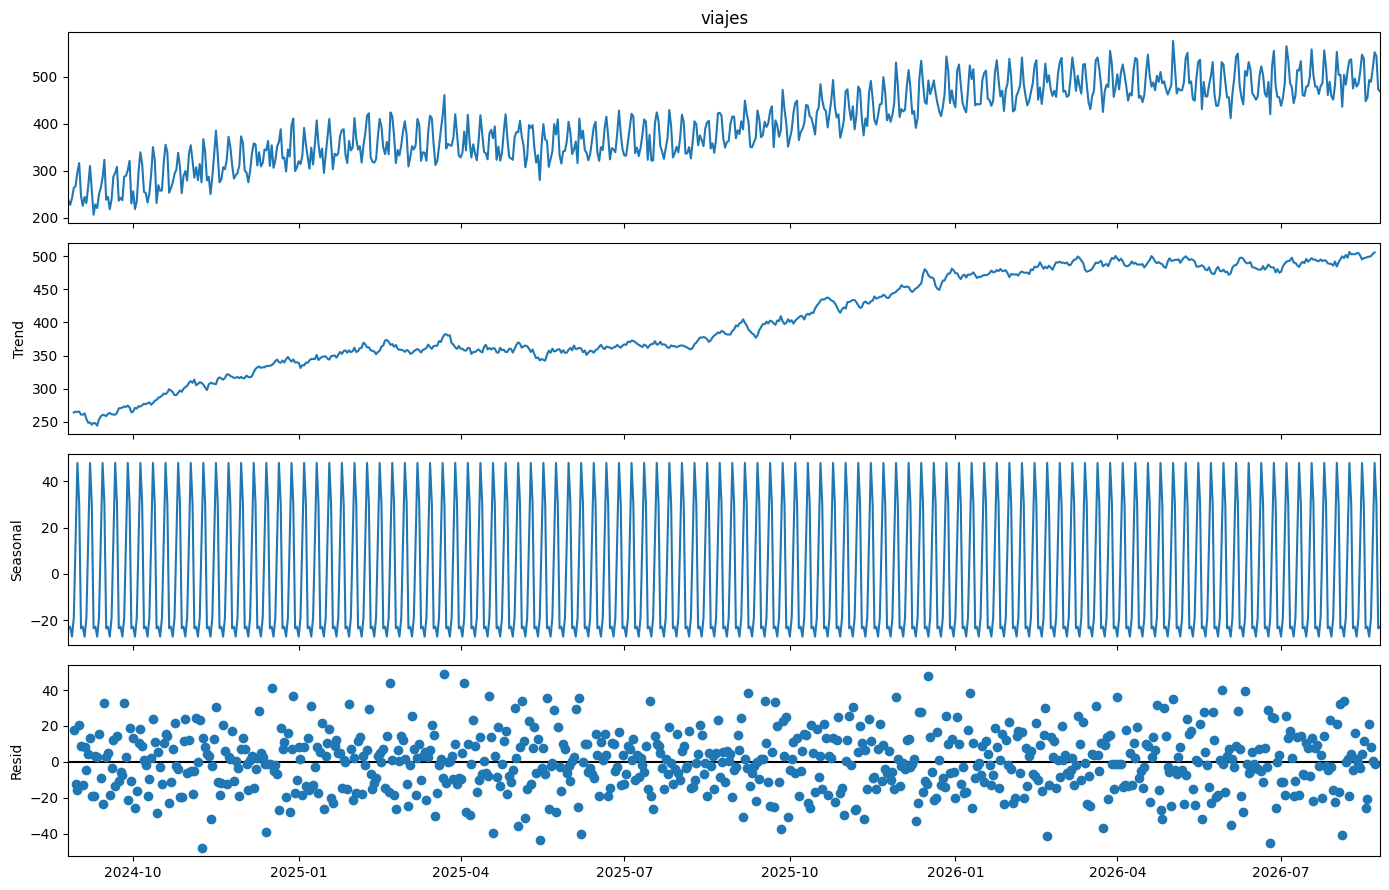

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

descomposicion = seasonal_decompose(serie, model="additive", period=7)

fig = descomposicion.plot()
fig.set_size_inches(14, 9)
plt.tight_layout()
plt.show()


## 4. Analizar cada componente por separado

**Por que:** el grafico combinado de `seasonal_decompose` es util, pero cuesta comparar bien las escalas. Vamos a graficar cada componente por separado para entenderlo mejor.


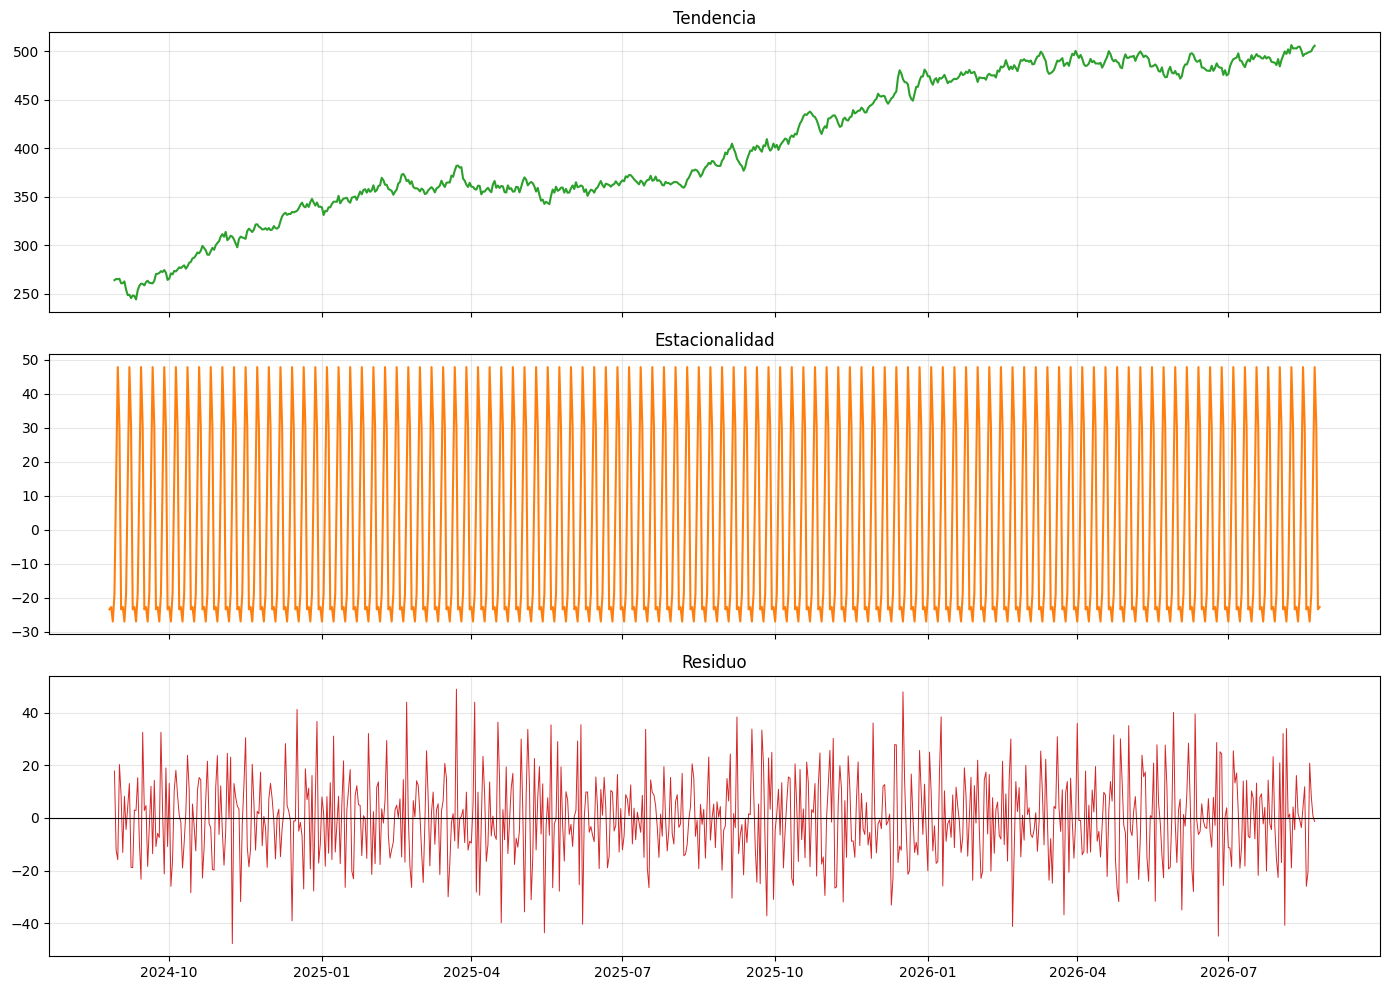

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(descomposicion.trend, color="#2ca02c")
axes[0].set_title("Tendencia")
axes[0].grid(alpha=0.3)

axes[1].plot(descomposicion.seasonal, color="#ff7f0e")
axes[1].set_title("Estacionalidad")
axes[1].grid(alpha=0.3)

axes[2].plot(descomposicion.resid, color="#d62728", linewidth=0.7)
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_title("Residuo")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Que mirar:**

- **Tendencia:** una linea que crece de forma sostenida a lo largo de los dos anios, con una ligera ondulacion (relacionada con la estacionalidad anual que agregamos al simular los datos). Confirma que CityScoot esta creciendo.
- **Estacionalidad:** un patron que se repite exactamente igual cada 7 dias: valores bajos entre semana y picos hacia el viernes-sabado-domingo, coherente con el uso de scooters para salidas de fin de semana.
- **Residuo:** deberia verse como ruido sin un patron claro, oscilando alrededor de cero. Si quedara algun patron visible ahi, seria senal de que el modelo (period=7, aditivo) no esta capturando toda la estructura de la serie.

**Interpretacion breve:** la serie de viajes de CityScoot esta dominada principalmente por la **tendencia** (el crecimiento sostenido explica la mayor parte del nivel de la serie), con una **estacionalidad semanal** clara y de menor magnitud superpuesta, y un residuo relativamente chico que indica que el modelo aditivo con periodo 7 explica bien la mayor parte del comportamiento de los datos.


In [7]:
amplitud_tendencia = descomposicion.trend.max() - descomposicion.trend.min()
amplitud_estacional = descomposicion.seasonal.max() - descomposicion.seasonal.min()
desvio_residuo = descomposicion.resid.std()

print(f"Amplitud de la tendencia (max-min): {amplitud_tendencia:.1f} viajes")
print(f"Amplitud de la estacionalidad (max-min): {amplitud_estacional:.1f} viajes")
print(f"Desvio estandar del residuo: {desvio_residuo:.1f} viajes")


Amplitud de la tendencia (max-min): 262.0 viajes
Amplitud de la estacionalidad (max-min): 74.9 viajes
Desvio estandar del residuo: 16.3 viajes


## 5. (Bonus opcional) Forecast simple con Random Forest

Esto **no es un requisito obligatorio** de la actividad, es solo un extra breve para mostrar como se podria usar la serie para predecir. Usamos un `RandomForestRegressor` con dos features simples: el valor de ayer (`lag_1`) y el valor de hace una semana (`lag_7`), ya que vimos que la estacionalidad semanal es fuerte.


MAE en el conjunto de test: 21.1 viajes


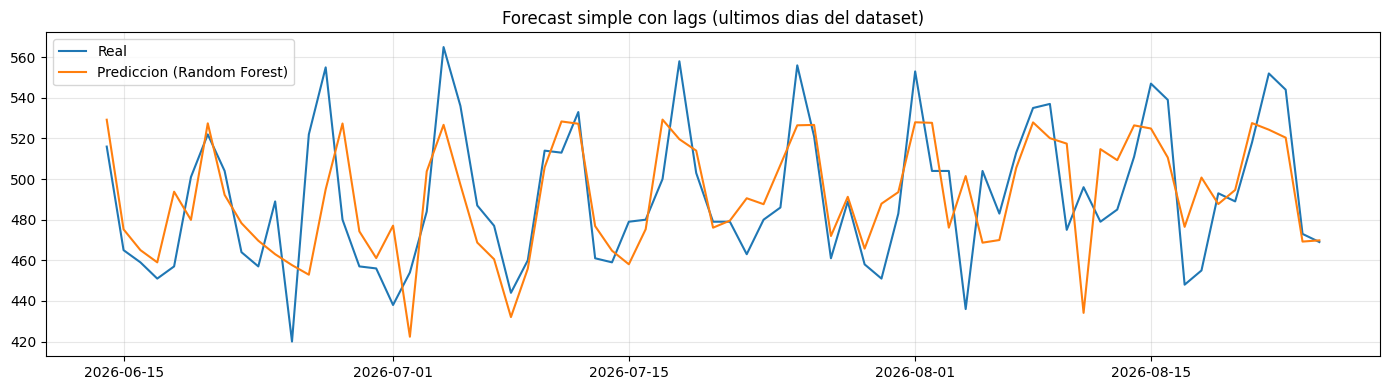

In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

df_lags = df.copy()
df_lags["lag_1"] = df_lags["viajes"].shift(1)
df_lags["lag_7"] = df_lags["viajes"].shift(7)
df_lags = df_lags.dropna().reset_index(drop=True)

corte = int(len(df_lags) * 0.9)
train, test = df_lags.iloc[:corte], df_lags.iloc[corte:]

X_train, y_train = train[["lag_1", "lag_7"]], train["viajes"]
X_test, y_test = test[["lag_1", "lag_7"]], test["viajes"]

modelo = RandomForestRegressor(n_estimators=200, random_state=42)
modelo.fit(X_train, y_train)
pred = modelo.predict(X_test)

mae = mean_absolute_error(y_test, pred)
print(f"MAE en el conjunto de test: {mae:.1f} viajes")

plt.figure(figsize=(14, 4))
plt.plot(test["fecha"], y_test.values, label="Real")
plt.plot(test["fecha"], pred, label="Prediccion (Random Forest)")
plt.legend()
plt.title("Forecast simple con lags (ultimos dias del dataset)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Conclusion

- La serie de viajes diarios de CityScoot muestra una **tendencia creciente** clara a lo largo de los dos anios analizados, consistente con una empresa en expansion.
- Existe una **estacionalidad semanal** bien definida: los viajes aumentan hacia el fin de semana y bajan entre semana, con un periodo de 7 dias.
- El **residuo** que queda despues de remover tendencia y estacionalidad es relativamente pequenio y no muestra un patron obvio, lo que indica que estos dos componentes explican gran parte del comportamiento de la serie.
- Para el negocio, esto sugiere que la planificacion de flota (cuantos scooters tener disponibles) deberia tener en cuenta tanto el crecimiento de largo plazo como el patron semanal (mas unidades disponibles los fines de semana).
